In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/CCPP_data.csv")
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [4]:
df.shape

(9568, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [6]:
df.describe()

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


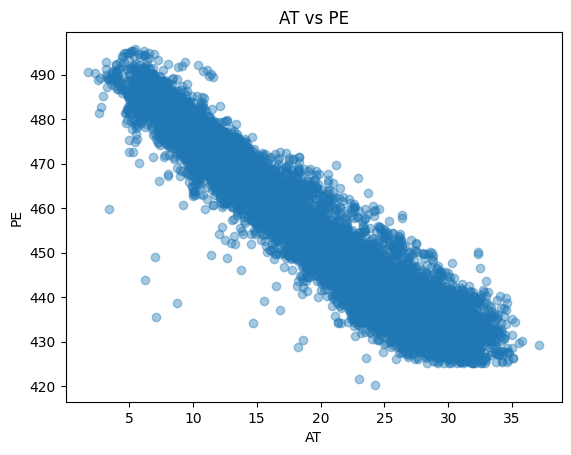

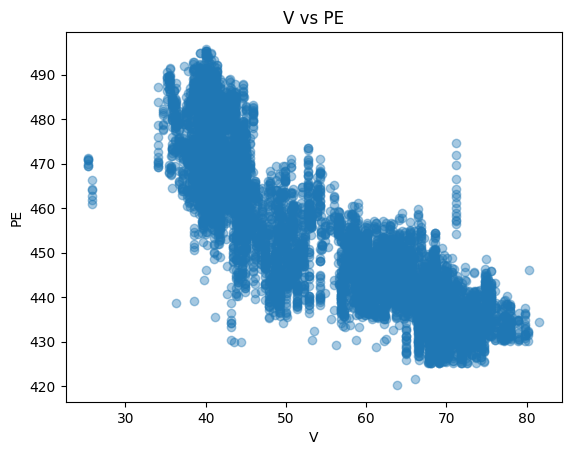

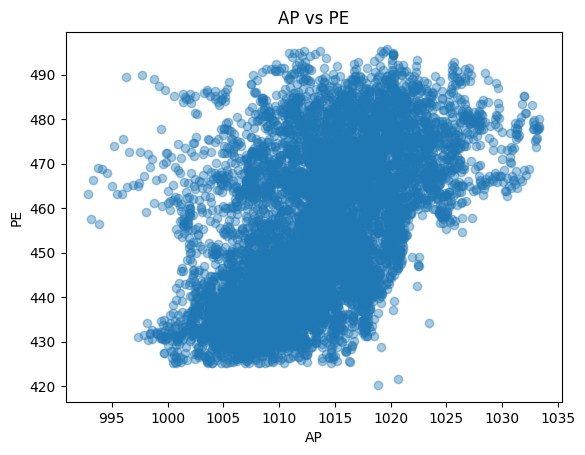

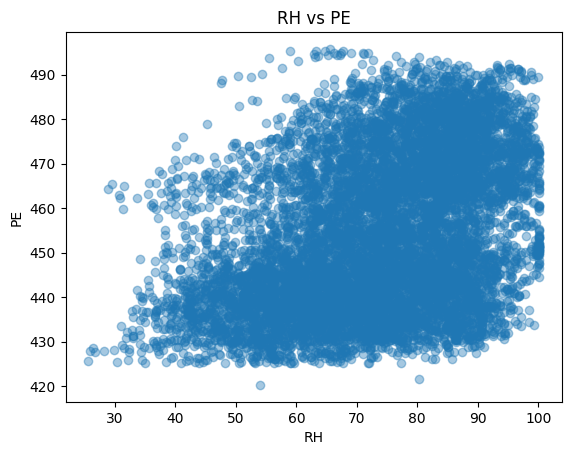

In [7]:
features = ["AT", "V", "AP", "RH"]

for feature in features:
  plt.figure()
  plt.scatter(x=df[feature], y=df["PE"], alpha=0.4)
  plt.xlabel(feature)
  plt.ylabel("PE")
  plt.title(f"{feature} vs PE")
  plt.show()

*   AT: strong negative correlation
*   V: negative correlation
*   AP: weaker positive correlation
*   RH: weaker positive/negative relationship





In [8]:
df[["AT", "V", "AP", "RH", "PE"]].corr()["PE"].drop("PE")

,PE
AT,-0.948128
V,-0.869780
AP,0.518429
RH,0.389794


In [9]:
correlations = df[["AT", "V", "AP", "RH", "PE"]].corr()["PE"].drop("PE")
correlations.sort_values(key=abs, ascending=False)

,PE
AT,-0.948128
V,-0.869780
AP,0.518429
RH,0.389794


## EDA Observations

From the scatter plots and correlation values, AT and V appear to have the strongest negative relationships with PE. This means that as temperature and exhaust vacuum increase, the net energy output tends to decrease.

AP and RH appear to have weaker relationships with PE, but they may still help the model when combined with other features.

In [10]:
# Features
X = df[["AT", "V", "AP", "RH"]]

# Target
y = df["PE"]

In [11]:
print(X.shape)
print(y.shape)

(9568, 4)
(9568,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 7654
Testing rows: 1914


## Train/Test Split

The dataset was split into 80% training data and 20% test data.

The training set will be used for model training and comparison.

The test set will be used only for final evaluation on unseen data.

In [15]:
linear_model = LinearRegression()

In [16]:
linear_model.fit(X_train, y_train)

LinearRegression()

In [17]:
print("Intercept:", linear_model.intercept_)
print("\nCoefficients:")
print(pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
}))

Intercept: 454.56911458941477

Coefficients:
  Feature  Coefficient
0      AT    -1.985900
1       V    -0.232094
2      AP     0.062200
3      RH    -0.158118


In [18]:
train_predictions = linear_model.predict(X_train)
test_predictions = linear_model.predict(X_test)

In [22]:
# Training metrics
train_mae= mean_absolute_error(y_train, train_predictions)
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
train_r2 = r2_score(y_train, train_predictions)

# Testing metrics
test_mae= mean_absolute_error(y_test, test_predictions)
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
test_r2 = r2_score(y_test, test_predictions)

In [23]:
print("Training Metrics:")
print("MAE:", train_mae)
print("RMSE:", train_rmse)
print("R2:", train_r2)

print("\nTesting Metrics:")
print("MAE:", test_mae)
print("RMSE:", test_rmse)
print("R2:", test_r2)

Training Metrics:
MAE: 3.6299902977038045
RMSE: 4.570930584824314
R2: 0.928331545565795

Testing Metrics:
MAE: 3.595913178273408
RMSE: 4.502633229532186
R2: 0.9301046431962188


## Model 1: Linear Regression

I trained a multiple linear regression model using all four features.
I evaluated the model using:
* MAE: Mean Absolute Error
* RMSE: Root Mean Squared Error
* $R^2$: Coefficient of Determination

## Model 1 Results:

The linear regression model achieved strong performance on both the training and testing datasets.

Testing Results:
* MAE: 3.60
* RMSE: 4.50
* $R^2$: 0.930

The model explains approximately 93% of variation in electrical energy output.

Temperature (AT) was the strongest predictor, showing a strong negative relationship with power output.

In [25]:
X_train_small = X_train[["AT", "V"]]
X_test_small = X_test[["AT", "V"]]

model2 = LinearRegression()
model2.fit(X_train_small, y_train)

LinearRegression()

In [26]:
train_predections2 = model2.predict(X_train_small)
test_predictions2 = model2.predict(X_test_small)

In [27]:
# Model 2 Training Metrics
train_mae2 = mean_absolute_error(y_train, train_predections2)
train_rmse2 = np.sqrt(mean_squared_error(y_train, train_predections2))
train_r22 = r2_score(y_train, train_predections2)

# Model 2 Testing Metrics
test_mae2 = mean_absolute_error(y_test, test_predictions2)
test_rmse2 = np.sqrt(mean_squared_error(y_test, test_predictions2))
test_r22 = r2_score(y_test, test_predictions2)

In [28]:
print("Model 2 Training Metrics:")
print("MAE:", train_mae2)
print("RMSE:", train_rmse2)
print("R2:", train_r22)

print("\nModel 2 Testing Metrics:")
print("MAE:", test_mae2)
print("RMSE:", test_rmse2)
print("R2:", test_r22)

Model 2 Training Metrics:
MAE: 3.923252435988442
RMSE: 4.966336571218301
R2: 0.9153959635145718

Model 2 Testing Metrics:
MAE: 3.8872214297422496
RMSE: 4.905954169440894
R2: 0.9170221542602933


## Model 2: Linear Regression
I trained a multiple linear regression model using 2 features only (AT and V). I evaluated the model using:

* MAE: Mean Absolute Error
* RMSE: Root Mean Squared Error
* $𝑅^2$ : Coefficient of Determination

## Model 2 Results:

Testing Results:

* MAE: 3.89
* RMSE: 4.90
* $𝑅^2$ : 0.917

## Model Comparison

Two models were compared.

### Model 1
Features: AT, V, AP, RH

### Model 2
Features: AT, V

Model 1 achieved the lowest RMSE and the highest $R^2$ on the test dataset.

Although AP and RH appeared weaker during exploratory analysis, including them improved overall model performence. This demonstrated that features can provide additional predictive value when used together, even if their individual relationships with the target appear weaker.